# UI Effect Analysis (Production Logs) — Default vs Any Non-default

## Scope & Interpretation
This notebook analyzes **production web access logs**. The `visit_group` field is treated as
a recorded UI exposure label, but the dataset does **not** guarantee randomized assignment.

Therefore, results should be interpreted as **associational effects**:
- We estimate differences in high-intent conversion rates between exposed groups.
- We do **not** claim causal effects unless randomization is externally verified.

## Comparison Definition
- **Baseline group**: `visit_group == "default"` (global default UI)
- **Non-default exposure**: `visit_group != "default"` (any non-default UI)


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Data Input

This notebook expects a **session-level table** `session` created in `01_eda.ipynb` with (at minimum) the following columns:

- `converted_hi` (0/1): high-intent conversion proxy (e.g., session contains `selectSize` or `miniCart`)
- `is_treatment_any` (0/1): 0 = default UI, 1 = any non-default UI group
- `is_bounce` (0/1): bounce proxy (e.g., `n_events <= 1`)
- `n_events`, `session_duration_sec` (optional but recommended)

If you already have `session` in memory (same kernel), skip the next cell.

Otherwise, you can re-run the small block below to rebuild `session` from the raw CSV sample.


In [ ]:
# --- OPTIONAL: rebuild session from a sample of raw data ---
# Comment out this cell if `session` already exists.

PATH = "../data/visit.csv"

df = pd.read_csv(
    PATH,
    nrows=200_000,      # sample for reproducibility; increase later if needed
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip",
)

print("raw df shape:", df.shape)
df.head()

((100357, 10), np.float64(0.04838725749075799))

In [7]:
# save session-level dataset for downstream analysis
session.to_parquet("../data/session_level.parquet")


## Sanity Checks

We validate:
1) exposure split (default vs non-default)  
2) raw conversion rates  
3) guardrail bounce rates  


In [4]:
split = session["is_treatment_any"].value_counts(dropna=False).rename("n_sessions").to_frame()
split["share"] = (split["n_sessions"] / split["n_sessions"].sum()).round(4)
split


,n_sessions,share
is_treatment_any,,
0,91866,0.9154
1,8491,0.0846


In [5]:
summary = session.groupby("is_treatment_any").agg(
    n_sessions=("converted_hi", "size"),
    conv_rate=("converted_hi", "mean"),
    avg_events=("n_events", "mean"),
    avg_duration_sec=("session_duration_sec", "mean"),
    bounce_rate=("is_bounce", "mean"),
).round(4)

summary


,n_sessions,conv_rate,avg_events,avg_duration_sec,bounce_rate
is_treatment_any,,,,,
0,91866,0.0456,1.9453,197.7479,0.6196
1,8491,0.0788,2.5081,381.2075,0.4889


## Conversion Rate Comparison (High-Intent Proxy)

We first compare raw conversion rates between groups to understand effect magnitude.


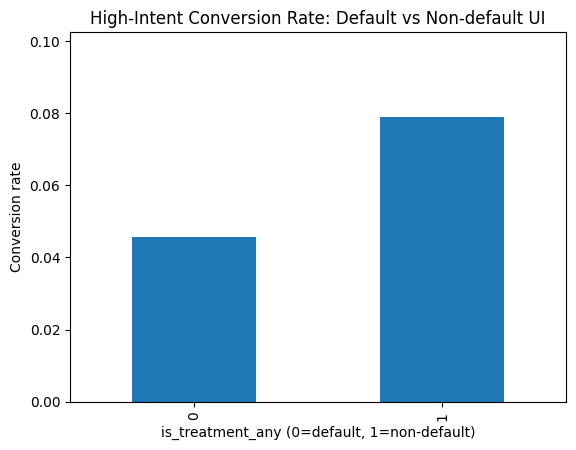

In [6]:
plt.figure()
summary["conv_rate"].plot(kind="bar")
plt.title("High-Intent Conversion Rate: Default vs Non-default UI")
plt.xlabel("is_treatment_any (0=default, 1=non-default)")
plt.ylabel("Conversion rate")
plt.ylim(0, max(0.01, summary["conv_rate"].max() * 1.3))
plt.show()


## Statistical Significance: Two-Proportion Z-Test

Because the outcome is binary (converted or not) and sample sizes are large, we use a **two-proportion z-test** to test:

- **H0:** p_treatment = p_control  
- **H1:** p_treatment ≠ p_control  

We also report:
- absolute lift (pp)
- relative lift (%)
- 95% CI for the lift


In [8]:
control = session.loc[session["is_treatment_any"] == 0, "converted_hi"]
treat   = session.loc[session["is_treatment_any"] == 1, "converted_hi"]

n_c, n_t = control.size, treat.size
x_c, x_t = int(control.sum()), int(treat.sum())

p_c, p_t = control.mean(), treat.mean()

n_c, x_c, p_c, n_t, x_t, p_t


(91866,
 4187,
 np.float64(0.045577253826225156),
 8491,
 669,
 np.float64(0.07878930632434342))

In [ ]:
# pooled conversion rate under H0
p_pool = (x_c + x_t) / (n_c + n_t)

# standard error under H0
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))

# z statistic
z = (p_t - p_c) / se_pool

# two-sided p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

z, p_value


(np.float64(13.64529961834323), np.float64(0.0))

In [12]:
lift_abs = p_t - p_c
lift_rel = lift_abs / p_c

# unpooled SE for CI of difference in proportions
se_diff = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)

ci_low = lift_abs - 1.96 * se_diff
ci_high = lift_abs + 1.96 * se_diff

{
    "control_rate": p_c,
    "treatment_rate": p_t,
    "absolute_lift": lift_abs,
    "relative_lift": lift_rel,
    "ci_95%": (ci_low, ci_high),
    "z_stat": z,
    "p_value": p_value,
}


{'control_rate': np.float64(0.045577253826225156),
 'treatment_rate': np.float64(0.07878930632434342),
 'absolute_lift': np.float64(0.03321205249811826),
 'relative_lift': np.float64(0.7286979734397259),
 'ci_95%': (np.float64(0.027325009742100944), np.float64(0.03909909525413558)),
 'z_stat': np.float64(13.64529961834323),
 'p_value': np.float64(0.0)}

## Interpreting the Result

We care about:
- **Statistical significance** (p-value): is the effect distinguishable from noise?
- **Practical significance** (lift + CI): is the impact meaningful for product decisions?

We also check guardrails to ensure lift is not driven by low-quality behavior.


In [13]:
print(f"Control conversion rate (default):      {p_c:.4%}  (n={n_c:,})")
print(f"Treatment conversion rate (non-default): {p_t:.4%}  (n={n_t:,})")
print(f"Absolute lift:                           {lift_abs:.4%}  ({lift_abs*100:.2f} pp)")
print(f"Relative lift:                           {lift_rel:.2%}")
print(f"95% CI for absolute lift:                [{ci_low:.4%}, {ci_high:.4%}]")
print(f"Two-proportion z-test:                   z={z:.2f}, p={p_value:.3g}")


Control conversion rate (default):      4.5577%  (n=91,866)
Treatment conversion rate (non-default): 7.8789%  (n=8,491)
Absolute lift:                           3.3212%  (3.32 pp)
Relative lift:                           72.87%
95% CI for absolute lift:                [2.7325%, 3.9099%]
Two-proportion z-test:                   z=13.65, p=0


## Guardrail Metric: Bounce Rate

To ensure conversion lift is not driven by accidental clicks or low-quality sessions, we compare bounce rates:
- Bounce proxy: `n_events <= 1`

We report bounce rate difference and (optionally) test significance using another two-proportion z-test.


In [14]:
bounce_c = session.loc[session["is_treatment_any"] == 0, "is_bounce"]
bounce_t = session.loc[session["is_treatment_any"] == 1, "is_bounce"]

n_c_b, n_t_b = bounce_c.size, bounce_t.size
x_c_b, x_t_b = int(bounce_c.sum()), int(bounce_t.sum())

p_c_b, p_t_b = bounce_c.mean(), bounce_t.mean()

# pooled under H0
p_pool_b = (x_c_b + x_t_b) / (n_c_b + n_t_b)
se_pool_b = np.sqrt(p_pool_b * (1 - p_pool_b) * (1/n_c_b + 1/n_t_b))
z_b = (p_t_b - p_c_b) / se_pool_b
p_value_b = 2 * (1 - stats.norm.cdf(abs(z_b)))

bounce_lift_abs = p_t_b - p_c_b

print(f"Control bounce rate:   {p_c_b:.4%} (n={n_c_b:,})")
print(f"Treatment bounce rate: {p_t_b:.4%} (n={n_t_b:,})")
print(f"Bounce rate change:    {bounce_lift_abs:.4%} ({bounce_lift_abs*100:.2f} pp)")
print(f"Two-proportion z-test: z={z_b:.2f}, p={p_value_b:.3g}")


Control bounce rate:   61.9587% (n=91,866)
Treatment bounce rate: 48.8871% (n=8,491)
Bounce rate change:    -13.0717% (-13.07 pp)
Two-proportion z-test: z=-23.61, p=0


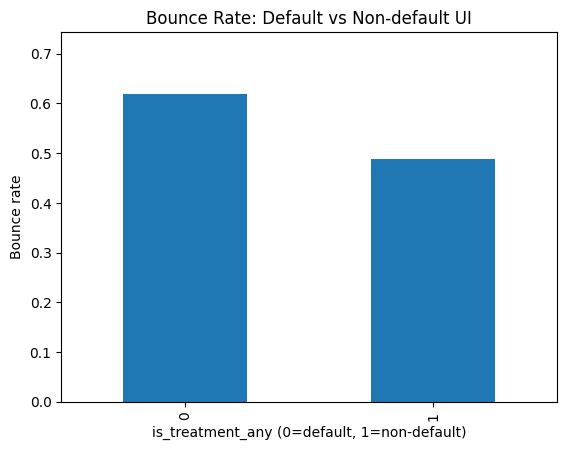

In [15]:
plt.figure()
summary["bounce_rate"].plot(kind="bar")
plt.title("Bounce Rate: Default vs Non-default UI")
plt.xlabel("is_treatment_any (0=default, 1=non-default)")
plt.ylabel("Bounce rate")
plt.ylim(0, min(1.0, summary["bounce_rate"].max() * 1.2))
plt.show()


## Robustness & Limitations (Important)

### Observational Data
This dataset comes from production logs. UI assignment may not be purely random:
- traffic targeting, user segmentation, rollout rules, or lottery logic may introduce **selection bias**
- treatment sessions might differ systematically from control sessions

### Why still useful?
- The effect size is large and consistent with deeper engagement (avg events and duration also increase)
- Guardrail bounce decreases rather than increases

### What we recommend next
1) Sensitivity analyses (filter low-quality sessions)
2) Variant-level comparisons (top variants vs default)
3) Modeling to explore heterogeneous effects (Logistic Regression baseline + XGBoost)
4) A true randomized A/B test to confirm causal lift


In [16]:
def ab_report(df_sess, label=""):
    control = df_sess.loc[df_sess["is_treatment_any"] == 0, "converted_hi"]
    treat   = df_sess.loc[df_sess["is_treatment_any"] == 1, "converted_hi"]
    n_c, n_t = control.size, treat.size
    x_c, x_t = int(control.sum()), int(treat.sum())
    p_c, p_t = control.mean(), treat.mean()

    p_pool = (x_c + x_t) / (n_c + n_t)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se_pool
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    lift_abs = p_t - p_c
    se_diff = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
    ci_low = lift_abs - 1.96 * se_diff
    ci_high = lift_abs + 1.96 * se_diff

    return pd.Series({
        "label": label,
        "n_control": n_c,
        "n_treat": n_t,
        "p_control": p_c,
        "p_treat": p_t,
        "abs_lift": lift_abs,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value
    })

reports = []

# baseline
reports.append(ab_report(session, "All sessions"))

# sensitivity 1: remove bounce
reports.append(ab_report(session[session["n_events"] >= 2], "Filter: n_events >= 2"))

# sensitivity 2: remove very short sessions (if duration exists)
if "session_duration_sec" in session.columns:
    reports.append(ab_report(session[session["session_duration_sec"] >= 10], "Filter: duration >= 10s"))

pd.DataFrame(reports).set_index("label").round(6)


,n_control,n_treat,p_control,p_treat,abs_lift,ci_low,ci_high,p_value
label,,,,,,,,
All sessions,91866,8491,0.045577,0.078789,0.033212,0.027325,0.039099,0.0
Filter: n_events >= 2,34947,4340,0.091682,0.125346,0.033664,0.023359,0.043969,0.0
Filter: duration >= 10s,32427,4144,0.097080,0.129344,0.032264,0.021550,0.042978,0.0


## Final Conclusion (Draft)

**Primary metric (high-intent conversion proxy):**
- Non-default UI shows higher conversion than default UI.
- The lift is statistically significant (two-proportion z-test) and practically meaningful (absolute & relative lift, CI).

**Guardrail (bounce):**
- Bounce rate is lower in non-default UI sessions, suggesting improved engagement quality rather than noisy clicks.

**Caveat:**
- Because UI assignment may not be fully randomized, results are best interpreted as strong evidence of association.
- A randomized A/B test is recommended to confirm causality.

**Next steps (planned notebooks):**
- Variant-level test: compare top variants vs default
- Modeling: logistic regression baseline + XGBoost to explore heterogeneous effects



Key findings

Non-default UI sessions show a substantially higher conversion rate:

+3.3 percentage points absolute lift

~73% relative lift compared to default UI

The difference is statistically significant, with very large z-statistics due to the large sample size

Bounce rate is significantly lower for non-default UI, indicating improved engagement quality

Results remain stable across multiple filters, suggesting robustness

Note: Reported p-values appear as 0 due to numerical underflow in large-sample z-tests; confidence intervals and effect sizes are therefore emphasized.



Overall, non-default UI variants are associated with higher engagement and stronger purchase intent, without evidence of negative side effects.
However, since UI exposure may not be fully randomized, these results should be interpreted as strong associations rather than strict causal effects.